In [ ]:
from google.colab import files
uploaded = files.upload()


TypeError: 'NoneType' object is not subscriptable

In [ ]:
import pandas as pd

# Load the dataset (use the correct path and separator!)
df = pd.read_csv("phenotype_data.csv", sep="\t")  # or sep="," if it's comma-separated


In [ ]:
print("Shape of dataset:", df.shape)
print(f"Rows (participants): {df.shape[0]}")
print(f"Columns (variables): {df.shape[1]}")


Shape of dataset: (502399, 1)
Rows (participants): 502399
Columns (variables): 1


In [ ]:
!pip install scikit-learn pandas


In [ ]:
print(df.columns.tolist())


['FID IID FT FT2 FT3 age age2 sex BMI T2D RG MDD PC1 PC2 PC3 PC4 PC5 PC6 sumphq9 ethnicity HbA1c_0_percent']


In [ ]:
# Descriptive stats for BMI
print("Descriptive Statistics for BMI:")
print(df['BMI'].describe())

# Descriptive stats for HbA1c
print("\nDescriptive Statistics for HbA1c:")
print(df['HbA1c_0_percent'].describe())

# Descriptive stats for PHQ-9 depression score
print("\nDescriptive Statistics for PHQ-9:")
print(df['sumphq9'].describe())


Descriptive Statistics for BMI:


KeyError: 'BMI'

In [ ]:
import pandas as pd
df = pd.read_csv("phenotype_data.csv", sep="\s+")  # this means "one or more spaces"


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-488661992.py:2: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("phenotype_data.csv", sep="\s+")  # this means "one or more spaces"


FileNotFoundError: [Errno 2] No such file or directory: 'phenotype_data.csv'

In [ ]:
print(df.columns.tolist())


['FID', 'IID', 'FT', 'FT2', 'FT3', 'age', 'age2', 'sex', 'BMI', 'T2D', 'RG', 'MDD', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'sumphq9', 'ethnicity', 'HbA1c_0_percent']


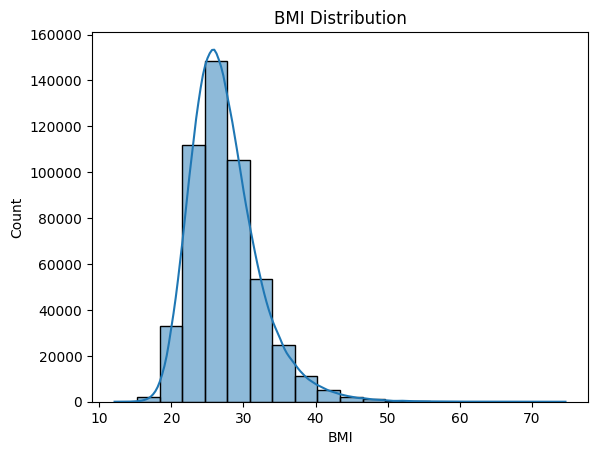

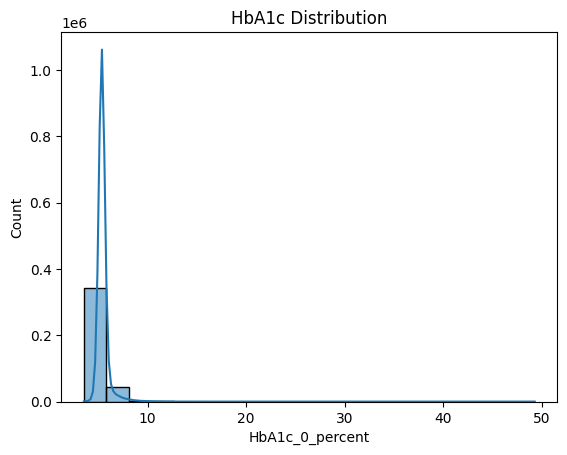

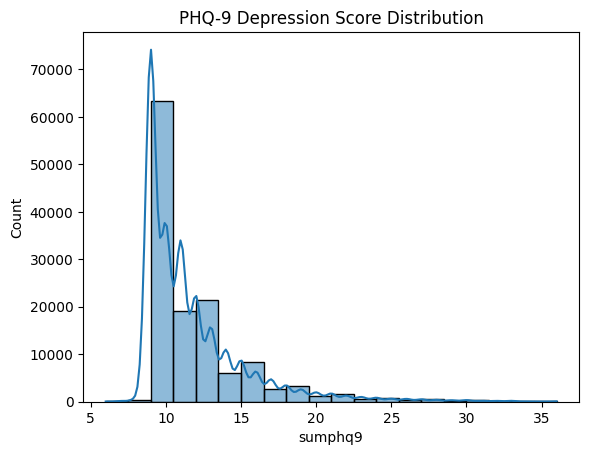

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# BMI
sns.histplot(df['BMI'], bins=20, kde=True)
plt.title('BMI Distribution')
plt.show()

# HbA1c
sns.histplot(df['HbA1c_0_percent'], bins=20, kde=True)
plt.title('HbA1c Distribution')
plt.show()

# PHQ-9
sns.histplot(df['sumphq9'], bins=20, kde=True)
plt.title('PHQ-9 Depression Score Distribution')
plt.show()


In [ ]:
print("Descriptive Statistics for BMI:")
print(df['BMI'].describe())

print("\nDescriptive Statistics for HbA1c:")
print(df['HbA1c_0_percent'].describe())

print("\nDescriptive Statistics for PHQ-9 Depression Score:")
print(df['sumphq9'].describe())

# Split data
males = df[df['sex'] == 1]
females = df[df['sex'] == 2]

# Descriptive stats for males
print("Descriptive Statistics for Males:")
print(males[['BMI', 'HbA1c_0_percent', 'sumphq9']].describe())

# Descriptive stats for females
print("\nDescriptive Statistics for Females:")
print(females[['BMI', 'HbA1c_0_percent', 'sumphq9']].describe())



Descriptive Statistics for BMI:
count    499294.000000
mean         27.432716
std           4.802884
min          12.121200
25%          24.138900
50%          26.743300
75%          29.908400
max          74.683700
Name: BMI, dtype: float64

Descriptive Statistics for HbA1c:
count    390372.000000
mean          5.441465
std           0.594618
min           3.522495
25%           5.142040
50%           5.370789
75%           5.608688
max          49.290635
Name: HbA1c_0_percent, dtype: float64

Descriptive Statistics for PHQ-9 Depression Score:
count    130728.000000
mean         11.729308
std           3.644878
min           6.000000
25%           9.000000
50%          11.000000
75%          13.000000
max          36.000000
Name: sumphq9, dtype: float64
Descriptive Statistics for Males:
                 BMI  HbA1c_0_percent       sumphq9
count  227433.000000    179401.000000  57403.000000
mean       27.838718         5.473674     11.395676
std         4.247753         0.668447      3.

BMI_category
Overweight     212074
Normal         162369
Obese          125330
Underweight      2626
Name: count, dtype: int64


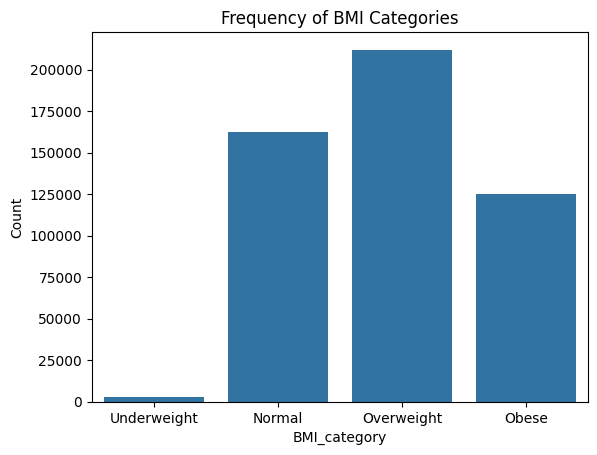

In [ ]:
# Categorize BMI
def bmi_category(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 25: return 'Normal'
    elif bmi < 30: return 'Overweight'
    else: return 'Obese'

df['BMI_category'] = df['BMI'].apply(bmi_category)

# Frequency of each BMI category
print(df['BMI_category'].value_counts())

# Bar plot
sns.countplot(data=df, x='BMI_category', order=['Underweight', 'Normal', 'Overweight', 'Obese'])
plt.title('Frequency of BMI Categories')
plt.ylabel('Count')
plt.show()


In [ ]:
import statsmodels.api as sm

# Drop missing values from both X and y
data = df[['BMI', 'HbA1c_0_percent']].dropna()

X = data['BMI']
y = data['HbA1c_0_percent']

# Add constant (intercept term)
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

# Show regression summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        HbA1c_0_percent   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                 2.403e+04
Date:                Tue, 17 Jun 2025   Prob (F-statistic):               0.00
Time:                        13:02:00   Log-Likelihood:            -3.3726e+05
No. Observations:              389141   AIC:                         6.745e+05
Df Residuals:                  389139   BIC:                         6.745e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6165      0.005    855.238      0.0

In [ ]:
import statsmodels.api as sm

# Keep only rows where BMI, HbA1c, and T2D are all not missing
data = df[['BMI', 'HbA1c_0_percent', 'T2D']].dropna()

# Independent variables
X = data[['BMI', 'HbA1c_0_percent']]

# Dependent variable
y = data['T2D']

# Add constant (intercept)
X = sm.add_constant(X)

# Fit the logistic regression model
logit_model = sm.Logit(y, X).fit()

# Show results
print(logit_model.summary())


ValueError: endog must be in the unit interval.

In [ ]:
print(df['T2D'].unique())


[nan  1.  2.]


In [ ]:
import statsmodels.api as sm

# Step 1: Create a copy with valid T2D entries
data = df[df['T2D'].isin([1, 2])][['BMI', 'HbA1c_0_percent', 'T2D']].dropna()

# Step 2: Recode T2D: 1 → 0 (no), 2 → 1 (yes)
data['T2D'] = data['T2D'].replace({1: 0, 2: 1})

# Step 3: Build logistic regression model
X = sm.add_constant(data[['BMI', 'HbA1c_0_percent']])
y = data['T2D']

# Step 4: Fit the model
logit_model = sm.Logit(y, X).fit()

# Step 5: Show results
print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.182943
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                    T2D   No. Observations:               256998
Model:                          Logit   Df Residuals:                   256995
Method:                           MLE   Df Model:                            2
Date:                Tue, 17 Jun 2025   Pseudo R-squ.:                  0.4920
Time:                        13:05:58   Log-Likelihood:                -47016.
converged:                       True   LL-Null:                       -92552.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -28.4513      0.148   -192.690      0.000     -28.741     -28.162
BMI           

In [ ]:
# Numeric correlation matrix
corr_matrix = df[['BMI', 'HbA1c_0_percent', 'sumphq9']].corr()
print(corr_matrix)


                      BMI  HbA1c_0_percent  sumphq9
BMI              1.000000         0.241152  0.13398
HbA1c_0_percent  0.241152         1.000000  0.02452
sumphq9          0.133980         0.024520  1.00000


In [ ]:
from scipy.stats import zscore

# Apply z-score to relevant columns
df[['BMI_z', 'HbA1c_z', 'PHQ9_z']] = df[['BMI', 'HbA1c_0_percent', 'sumphq9']].apply(zscore)


/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


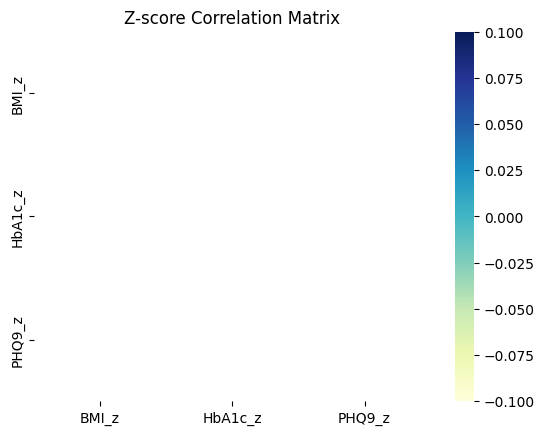

In [ ]:
z_corr = df[['BMI_z', 'HbA1c_z', 'PHQ9_z']].corr()
sns.heatmap(z_corr, annot=True, cmap='YlGnBu')
plt.title("Z-score Correlation Matrix")
plt.show()


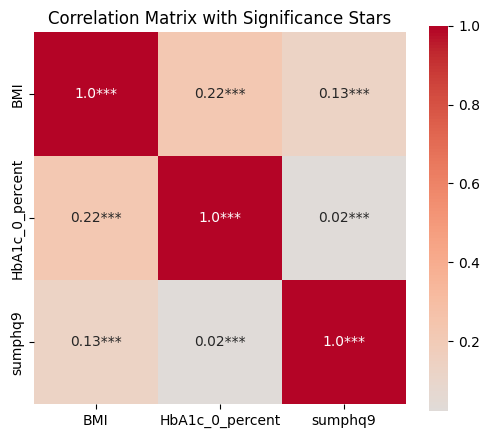

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Choose your variables
cols = ['BMI', 'HbA1c_0_percent', 'sumphq9']
data = df[cols].dropna()

# Create empty correlation and p-value matrices
corr = np.zeros((len(cols), len(cols)))
pval = np.zeros((len(cols), len(cols)))
stars = np.empty_like(corr, dtype=object)

# Fill in correlation values, p-values, and stars
for i in range(len(cols)):
    for j in range(len(cols)):
        r, p = pearsonr(data[cols[i]], data[cols[j]])
        corr[i, j] = r
        pval[i, j] = p

        # Add stars based on p-value
        if p < 0.001:
            stars[i, j] = '***'
        elif p < 0.01:
            stars[i, j] = '**'
        elif p < 0.05:
            stars[i, j] = '*'
        else:
            stars[i, j] = ''

# Convert to DataFrame
corr_df = pd.DataFrame(corr, columns=cols, index=cols)
star_df = pd.DataFrame(stars, columns=cols, index=cols)

# Combine numbers with stars
annot = corr_df.round(2).astype(str) + star_df

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_df, annot=annot, fmt='', cmap='coolwarm', center=0, square=True)
plt.title("Correlation Matrix with Significance Stars")
plt.show()


In [ ]:
male_df = df[df['sex'] == 1][['BMI', 'HbA1c_0_percent', 'sumphq9']].dropna()
female_df = df[df['sex'] == 2][['BMI', 'HbA1c_0_percent', 'sumphq9']].dropna()


In [ ]:
from scipy.stats import pearsonr

# Male raw
print("Male (Raw): BMI vs PHQ9:", pearsonr(male_df['BMI'], male_df['sumphq9']))
print("Male (Raw): HbA1c vs PHQ9:", pearsonr(male_df['HbA1c_0_percent'], male_df['sumphq9']))

# Female raw
print("\nFemale (Raw): BMI vs PHQ9:", pearsonr(female_df['BMI'], female_df['sumphq9']))
print("Female (Raw): HbA1c vs PHQ9:", pearsonr(female_df['HbA1c_0_percent'], female_df['sumphq9']))


Male (Raw): BMI vs PHQ9: PearsonRResult(statistic=np.float64(0.12663695019932586), pvalue=np.float64(1.0961057280877048e-193))
Male (Raw): HbA1c vs PHQ9: PearsonRResult(statistic=np.float64(0.05109864692741909), pvalue=np.float64(7.427511241713666e-33))


ValueError: `x` and `y` must have length at least 2.

In [ ]:
print(female_df[['BMI', 'sumphq9']].dropna().shape)


(0, 2)


In [ ]:
import numpy as np
df['HbA1c_log'] = np.log1p(df['HbA1c'])  # log(1 + x) avoids log(0)


NameError: name 'df' is not defined